In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_json("../results/bmprefill_new.json")

print(data["device_count"].value_counts())

data

device_count
1    1000
2    1000
4    1000
Name: count, dtype: int64


,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-10-03 18:47:43.178102732,1.346669,1,1970,8192,1,False,0.270563,1,5
1,2025-10-03 18:47:47.151968241,1.745544,1,2334,8192,1,False,0.079736,1,4
2,2025-10-03 18:47:49.517744780,0.268987,1,714,8192,1,False,0.343138,1,9
3,2025-10-03 18:47:53.178592682,1.491625,1,2158,8192,1,False,0.648038,1,12
4,2025-10-03 18:47:55.621578693,0.254241,1,710,8192,1,False,0.063318,1,2
...,...,...,...,...,...,...,...,...,...,...
2995,2025-10-04 09:45:38.975986242,0.092708,4,116,8192,1,False,0.151517,1,20
2996,2025-10-04 09:45:43.355023384,0.215908,4,622,8192,1,False,0.283669,1,33
2997,2025-10-04 09:45:48.833411694,0.536709,4,1138,8192,1,False,0.669488,1,51
2998,2025-10-04 09:46:48.298382998,14.095458,4,7464,8192,1,False,0.807398,1,61


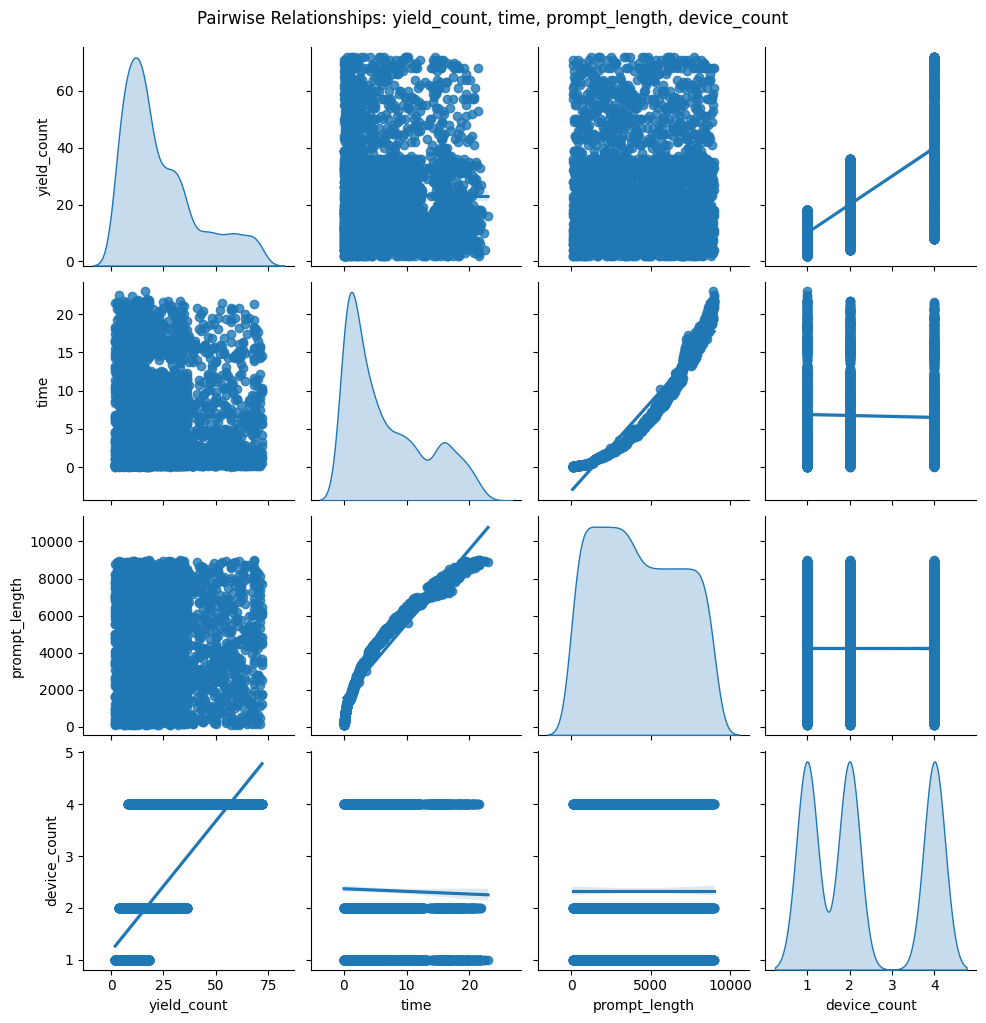

Correlation matrix:
                yield_count      time  prompt_length  device_count
yield_count       1.000000 -0.011030   7.732459e-03  7.092018e-01
time             -0.011030  1.000000   9.659997e-01 -2.559631e-02
prompt_length     0.007732  0.966000   1.000000e+00 -1.925447e-15
device_count      0.709202 -0.025596  -1.925447e-15  1.000000e+00


In [3]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "prompt_length", "device_count"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, prompt_length, device_count", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

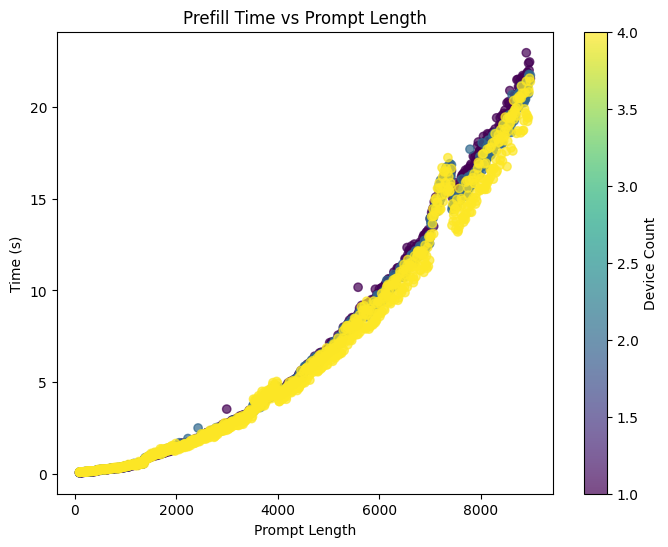

In [4]:
# Scatter plot: yield_count vs time, colored by prompt_length
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["prompt_length"], data["time"], c=data["device_count"], cmap="viridis", alpha=0.7)
plt.xlabel("Prompt Length")
plt.ylabel("Time (s)")
plt.title("Prefill Time vs Prompt Length")
cbar = plt.colorbar(sc)
cbar.set_label("Device Count")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

scaler = MinMaxScaler()
df = data.copy()
df["prompt_length_sq"] = df["prompt_length"]**2
X_raw = df[["prompt_length", "prompt_length_sq", "yield_count", "device_count", "time"]]
X_norm = scaler.fit_transform(X_raw)

X1 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length"]]
X2 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq"]]
X3 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count"]]
X4 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count", "device_count"]]
y = X_raw["time"]

X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

print(model4.summary())
print("F-test p-value for adding device_count:", model4.compare_f_test(model3)[1])
print("F-test p-value for adding yield_count:", model3.compare_f_test(model2)[1])
print("F-test p-value for adding prompt_length_sq:", model2.compare_f_test(model1)[1])

print("R-squared values:")
print("Model 1 (prompt_length):", model1.rsquared)
print("Model 2 (prompt_length + prompt_length_sq):", model2.rsquared)
print("Model 3 (prompt_length + prompt_length_sq + yield_count):", model3.rsquared)
print("Model 4 (prompt_length + prompt_length_sq + yield_count + device_count):", model4.rsquared)

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.279e+05
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        12:59:04   Log-Likelihood:                -2036.6
No. Observations:                3000   AIC:                             4083.
Df Residuals:                    2995   BIC:                             4113.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3444      0.026  

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.279e+05
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        12:59:04   Log-Likelihood:                -2036.6
No. Observations:                3000   AIC:                             4083.
Df Residuals:                    2995   BIC:                             4113.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3444      0.026  

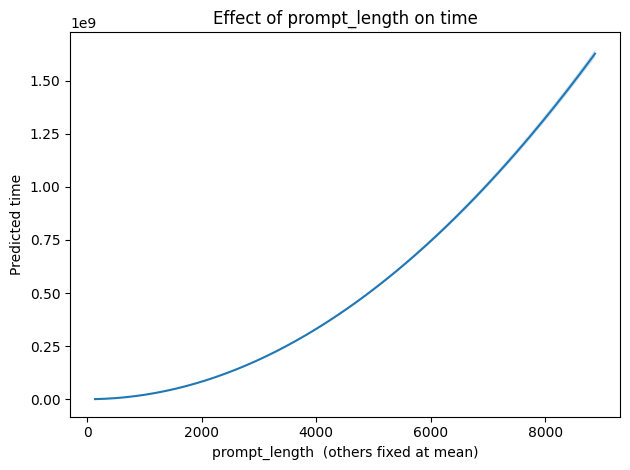

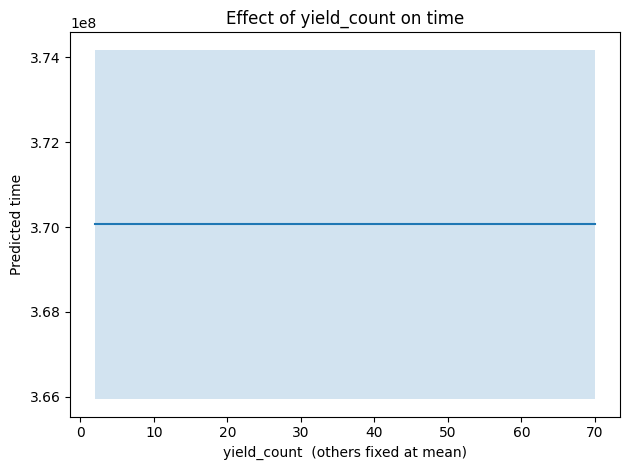

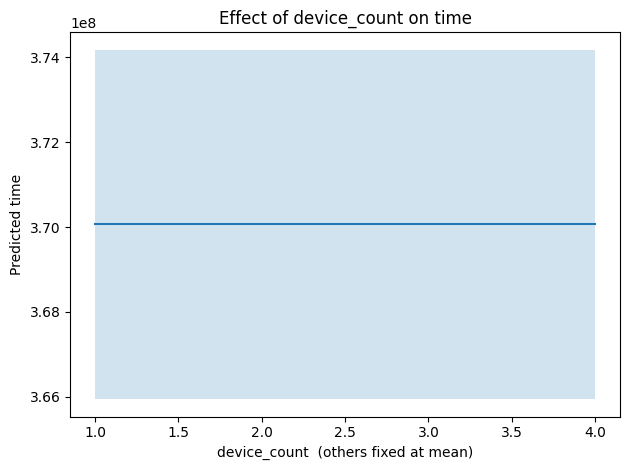

In [6]:
# pip install pandas numpy statsmodels matplotlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assume df already has: time, prompt_length, yield_count
df = data.copy()

# ------------------------------------------------------------
# 1) Add quadratic terms
# ------------------------------------------------------------
df["prompt_length_sq"] = df["prompt_length"]**2

# ------------------------------------------------------------
# 2) Fit quadratic OLS model
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_raw = df[["prompt_length", "yield_count", "prompt_length_sq", "device_count"]]
X_norm = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_norm, columns=X_raw.columns)
X = sm.add_constant(X)
y = df["time"]

quad_model = sm.OLS(y, X).fit()
print(quad_model.summary())

# ------------------------------------------------------------
# 3) Effect plot for prompt_length (quadratic)
# ------------------------------------------------------------
def quadratic_effect_plot(var_name, hold_vars, n=200):
    hold_vals = {k: df[k].mean() for k in hold_vars}
    vmin, vmax = np.percentile(df[var_name], [1, 99])
    grid = np.linspace(vmin, vmax, n)

    design = pd.DataFrame({
        "const": 1.0,
        "prompt_length": grid if var_name == "prompt_length" else hold_vals["prompt_length"],
        "yield_count": grid if var_name == "yield_count" else hold_vals["yield_count"],
        "prompt_length_sq": (grid if var_name == "prompt_length" else hold_vals["prompt_length"])**2,
        "device_count": grid if var_name == "device_count" else hold_vals["device_count"],
    })

    pred_res = quad_model.get_prediction(design).summary_frame(alpha=0.05)

    plt.figure()
    plt.plot(grid, pred_res["mean"])
    plt.fill_between(grid, pred_res["mean_ci_lower"], pred_res["mean_ci_upper"], alpha=0.2)
    plt.xlabel(var_name + f"  (others fixed at mean)")
    plt.ylabel("Predicted time")
    plt.title(f"Effect of {var_name} on time")
    plt.tight_layout()
    plt.show()

quadratic_effect_plot("prompt_length", ["yield_count", "device_count"])
quadratic_effect_plot("yield_count", ["prompt_length", "device_count"])
quadratic_effect_plot("device_count", ["prompt_length", "yield_count"])


In [7]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

# Fit a linear regression model for sensitivity analysis
lr = LinearRegression()
lr.fit(X_raw, y)

# Permutation importance (global sensitivity)
result = permutation_importance(lr, X_raw, y, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Display results
importances = pd.Series(result.importances_mean, index=X_raw.columns)
importances = importances.sort_values(ascending=False)
print("Permutation Importance (Global Sensitivity):")
print(importances)

Permutation Importance (Global Sensitivity):
prompt_length_sq    74.843523
device_count         0.042198
prompt_length        0.036775
yield_count          0.000927
dtype: float64


In [13]:
data = pd.read_json("../results/bsprefill_new.json")
data

,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-09-30 18:05:10.458356619,0.063167,1,94,8192,1,False,0,1,2
1,2025-09-30 18:05:12.646480560,0.061949,1,94,8192,1,False,1,1,18
2,2025-09-30 18:05:14.842609882,0.098730,1,269,8192,1,False,0,1,2
3,2025-09-30 18:05:17.075140953,0.099044,1,269,8192,1,False,1,1,18
4,2025-09-30 18:05:19.570640326,0.354685,1,1002,8192,1,False,0,1,2
...,...,...,...,...,...,...,...,...,...,...
234,2025-09-30 19:04:31.585992813,0.117691,4,269,8192,1,False,0,1,8
235,2025-09-30 19:04:35.419779539,0.123610,4,269,8192,1,False,1,1,72
236,2025-09-30 19:04:40.303120375,0.385831,4,1002,8192,1,False,0,1,8
237,2025-09-30 19:04:45.296552658,0.409162,4,1002,8192,1,False,1,1,72


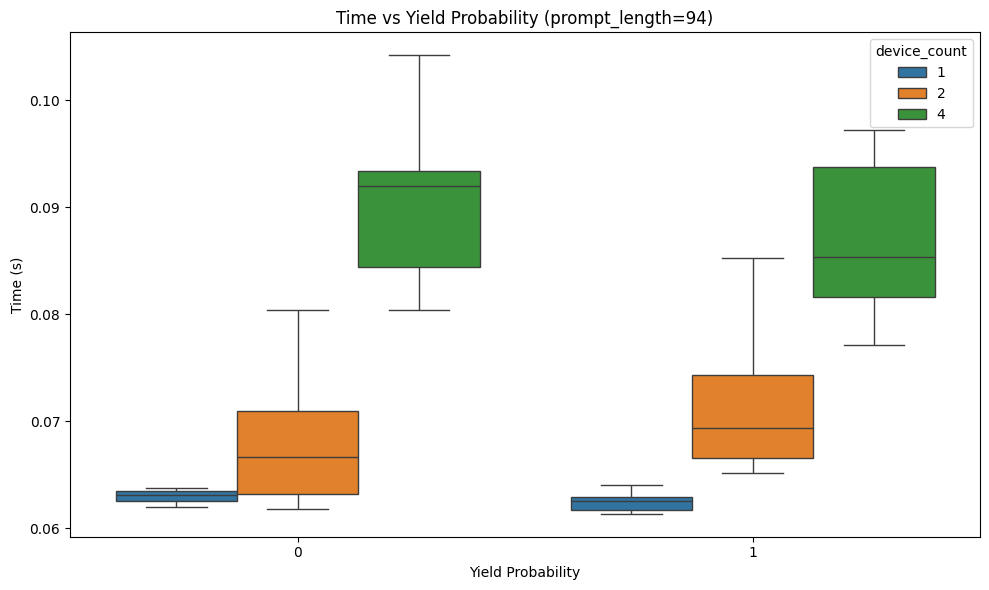

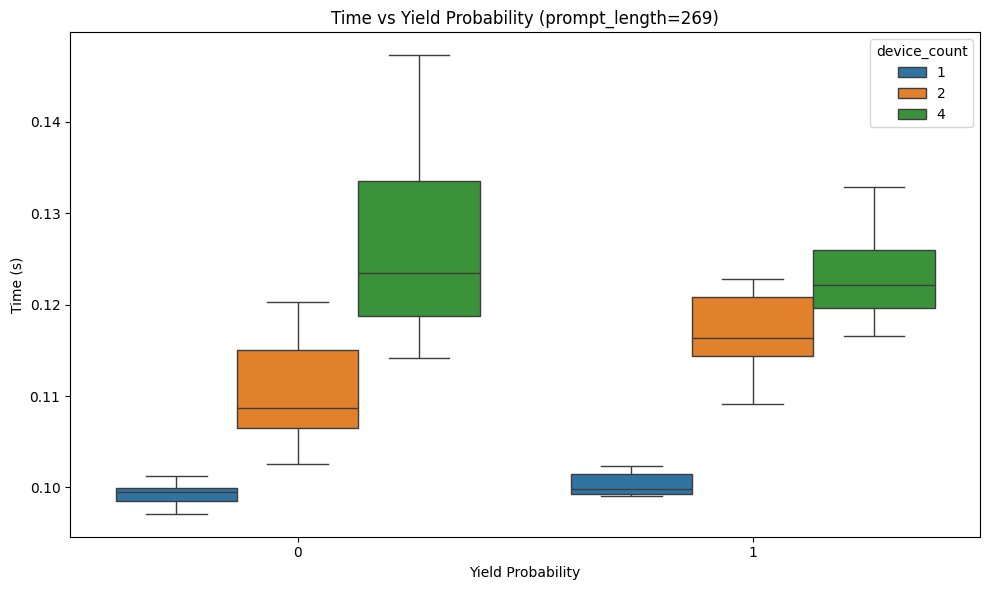

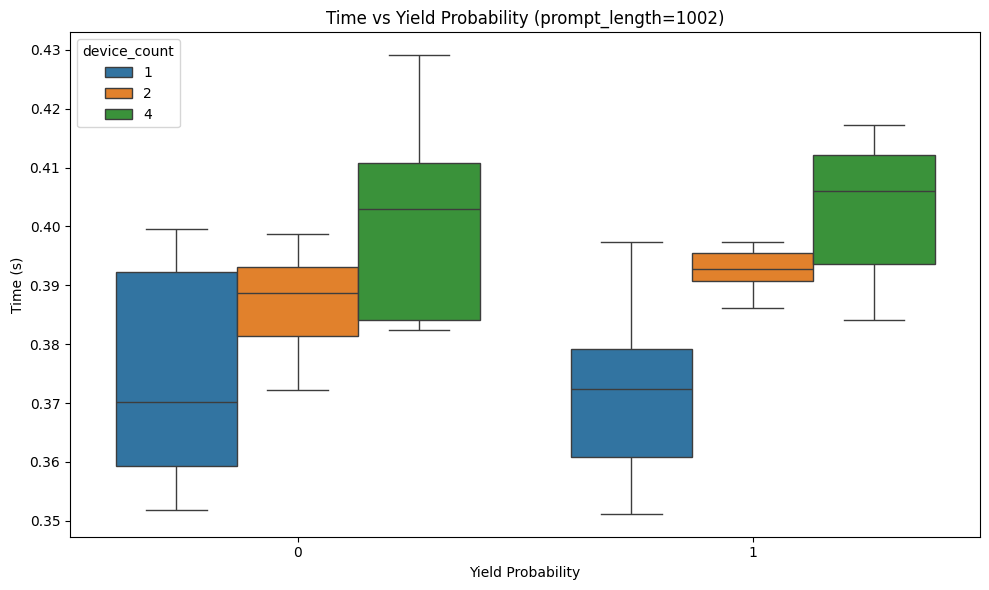

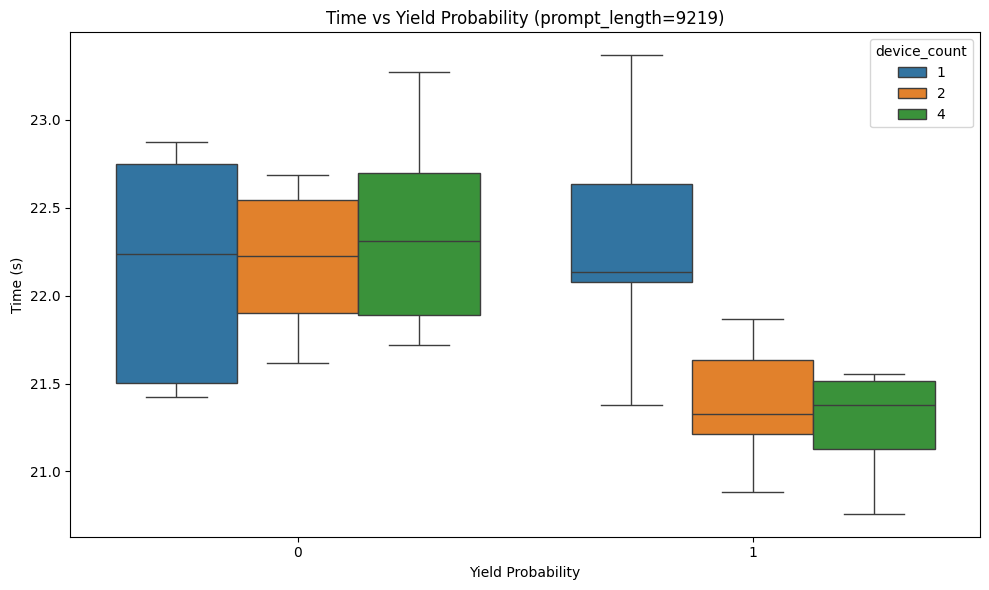

In [14]:
import seaborn as sns

for pl in sorted(data["prompt_length"].unique()):
    plt.figure(figsize=(10, 6))
    subset = data[data["prompt_length"] == pl]
    sns.boxplot(
        data=subset,
        x="yield_probability",
        y="time",
        hue="device_count",
        palette="tab10",
        showfliers=False
    )
    plt.title(f"Time vs Yield Probability (prompt_length={pl})")
    plt.xlabel("Yield Probability")
    plt.ylabel("Time (s)")
    plt.legend(title="device_count")
    plt.tight_layout()
    plt.show()
